# Project - Problem 1

Implementation of VO

## Import Modules

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import scipy.signal
import scipy.linalg
import mae6292.tools as mae6292
import importlib
import os
from pathlib import Path

from mae6292.imshow import cv2_imshow

# Problem 1 (20pt)

Under the folder `data/`, there is another set of images from a parking lot. The following codes load the intrinsic parameter `K` and the first image.

This is an easier data set as the motion is lateral, implying the baseline is large for easier triangulation. Perform VO to the 200 frames, and generate the following outcomes:

1. `prob1_bootstrap.png`: image showing the results of bootstrapping
2. `prob1.mp4`: video showing the results of localization and mapping at each frame
3. `prob1_map.png`: image showing the complete trajectory map

When using the above code, make it sure that the folder name and the image name are properly changed. You may need to tune the parameters.



K =
[[331.37    0.    320.   ]
 [  0.    369.568 240.   ]
 [  0.      0.      1.   ]]
First image shape: (480, 640)


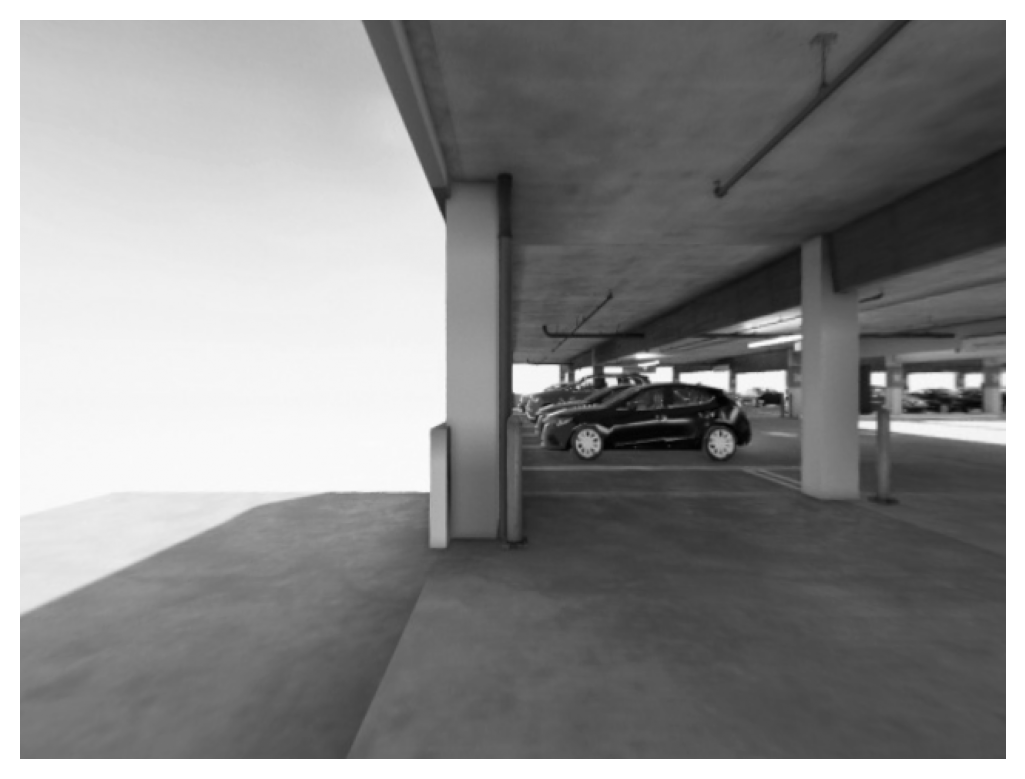

In [6]:
%matplotlib inline
# load K and first two images
K = np.loadtxt('data/K.txt')
img0 = cv2.imread('data/img_00000.png', cv2.IMREAD_GRAYSCALE)

# Main folders
DATA_DIR = Path('data')
OUT_DIR = Path('prob1_output')
OUT_DIR.mkdir(exist_ok=True)

# Problem 1 image sequence
N_FRAMES = 200
BOOTSTRAP_GAP = 10       # use img_00000 and img_00010 for a larger baseline
FPS = 10
DISPLAY_PROCESS = True   # keep True so output images can be saved for the video

# Load camera matrix and first images
imgB = cv2.imread(str(DATA_DIR / f'img_{BOOTSTRAP_GAP:05d}.png'), cv2.IMREAD_GRAYSCALE)

if img0 is None:
    raise FileNotFoundError('Could not find data/img_00000.png')
if imgB is None:
    raise FileNotFoundError(f'Could not find data/img_{BOOTSTRAP_GAP:05d}.png')

print('K =')
print(K)
print('First image shape:', img0.shape)
cv2_imshow(img0)


In [7]:
# Parameters for the first two-view initialization step
param_bootstrap = {
    # keypoints
    'W_harris_patch' : 4,
    'kappa_harris' : 0.08,
    'N_keypoint' : 3000,
    'W_nms' : 8,

    # KLT tracking
    'W_KLT' : 4,
    'tol_KLT_bidir' : 1,

    # essential matrix
    'tol_E' : 1,
    'tol_E_RANSAC_prob' : 0.99,

    # triangulation
    'tol_TRI_mu' : 1e-3,
    'tol_TRI_rep' : 1
}

# Parameters for sequential localization and mapping
param = {
    # keypoints
    'W_harris_patch' : 4,
    'kappa_harris' : 0.08,
    'N_keypoint' : 3000,
    'W_nms' : 8,

    # KLT tracking
    'W_KLT' : 4,
    'tol_KLT_bidir' : 1,

    # triangulation
    'tol_TRI_mu' : 1e-3,
    'tol_TRI_rep' : 1,

    # mapping
    'tol_keypoints_new' : 18
}

Number of initialized keypoints: 34
Number of initialized 3D points: 34


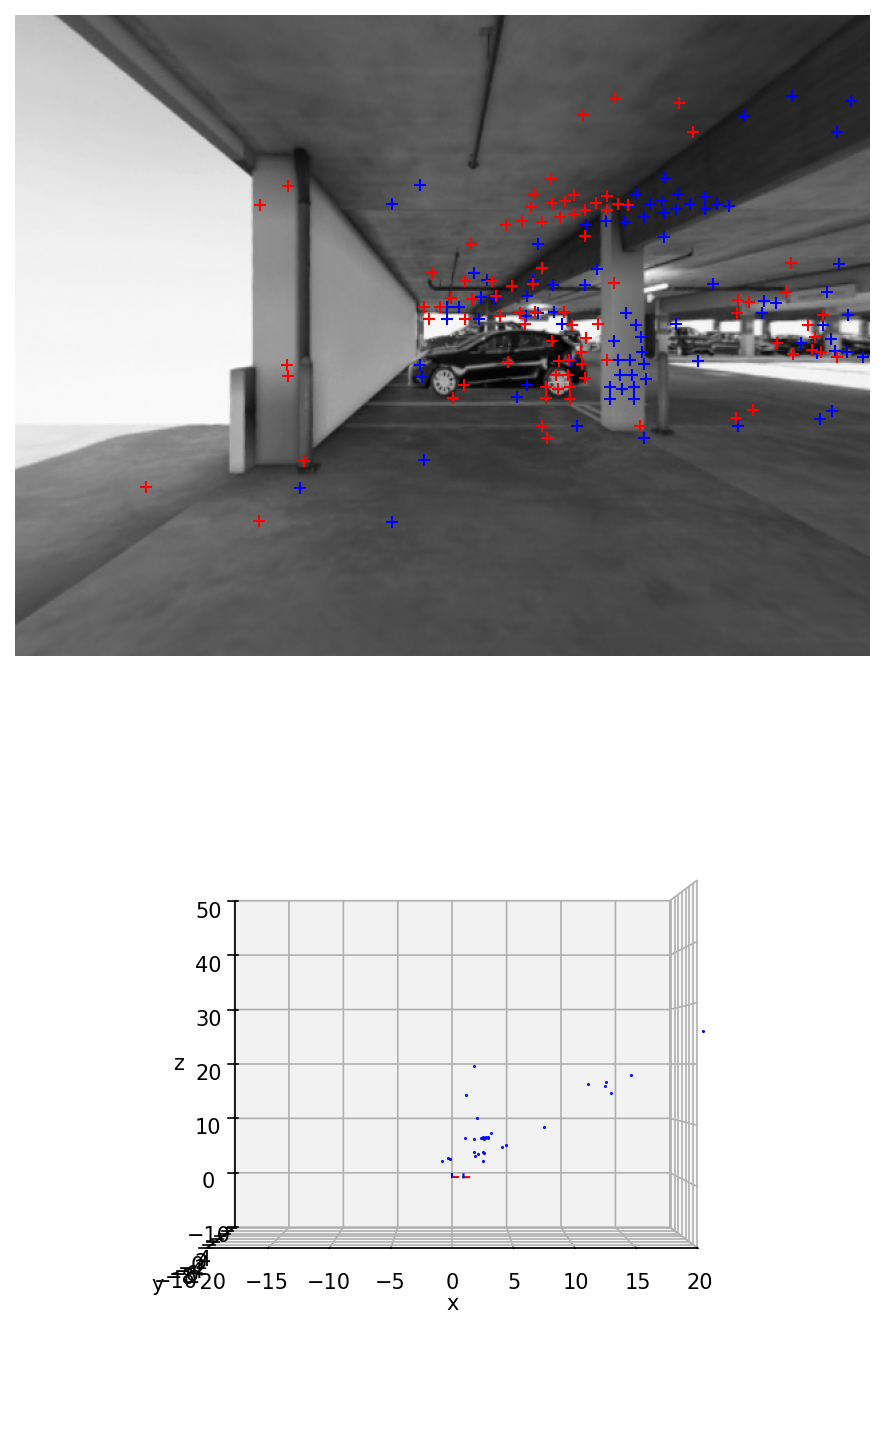

In [8]:
# Reload the course tools in case they were edited while the notebook was open.
importlib.reload(mae6292)

# Bootstrap VO using frame 0 and a later frame for a stronger lateral baseline.
keypoints0, p_W0, R1, T1 = mae6292.VO_bootstrap(
    img0,
    imgB,
    K,
    param_bootstrap,
    display=True
)

print('Number of initialized keypoints:', len(keypoints0))
print('Number of initialized 3D points:', p_W0.shape[1])

# Save the bootstrap display figure.
plt.savefig(OUT_DIR / 'prob1_bootstrap.png', dpi=200, bbox_inches='tight')

In [9]:
# Initial state. This follows the same structure as project.ipynb.
img_pre = img0
S_pre = mae6292.state(keypoints0, p_W0, [np.zeros((3, 1))])
C_pre = mae6292.candidate([], [], [], [])

# Save camera positions and all distinct map points.
T_W = np.zeros((3, N_FRAMES))
p_W = p_W0.copy()

# Process frames 1 through 199. Frame 0 is the world origin.
for i_frame in range(1, N_FRAMES):
    print('i_frame =', i_frame)

    gray_path = DATA_DIR / f'img_{i_frame:05d}.png'
    img = cv2.imread(str(gray_path), cv2.IMREAD_GRAYSCALE)
    img_bgr = cv2.imread(str(gray_path), cv2.IMREAD_COLOR)

    if img is None or img_bgr is None:
        print('Stopping early because this file was not found:', gray_path)
        break

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Main course-provided VO step.
    R, T, S, C, fig = mae6292.VO_localization_mapping(
        i_frame,
        img,
        img_rgb,
        img_pre,
        S_pre,
        C_pre,
        K,
        param,
        DISPLAY_PROCESS
    )

    # Update for next iteration.
    img_pre, S_pre, C_pre = img, S, C

    # Save each process figure for the output video.
    if DISPLAY_PROCESS:
        fig.savefig(OUT_DIR / f'{i_frame:05d}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)  # important for 200 frames

    # Camera center in the world frame.
    T_W[:, i_frame] = (-R.T @ T).flatten()

    # Add only map points that are reasonably distinct from points already saved.
    if S.p_W.shape[1] > 0 and p_W.shape[1] > 0:
        distances = scipy.spatial.distance.cdist(S.p_W.T, p_W.T, 'euclidean')
        distinct = np.where(np.min(distances, axis=1) > 3)[0]
        if len(distinct) > 0:
            p_W = np.append(p_W, S.p_W[:, distinct], axis=1)

print('Finished VO loop.')
print('Saved map points:', p_W.shape[1])

i_frame = 1
i_frame = 2
S_pre= 34 , KLT_matched= 33 , PnP_inliers= 32 , S_new =  440
C_pre= 2858 , KLT_matched= 1102 , TRI_inliers= 408 , C_new =  1027
i_frame = 3
S_pre= 440 , KLT_matched= 401 , PnP_inliers= 399 , S_new =  478
C_pre= 1027 , KLT_matched= 588 , TRI_inliers= 79 , C_new =  1849
i_frame = 4
S_pre= 478 , KLT_matched= 442 , PnP_inliers= 429 , S_new =  470
C_pre= 1849 , KLT_matched= 487 , TRI_inliers= 41 , C_new =  863
i_frame = 5
S_pre= 470 , KLT_matched= 432 , PnP_inliers= 428 , S_new =  459
C_pre= 863 , KLT_matched= 444 , TRI_inliers= 31 , C_new =  1821
i_frame = 6
S_pre= 459 , KLT_matched= 430 , PnP_inliers= 424 , S_new =  452
C_pre= 1821 , KLT_matched= 423 , TRI_inliers= 28 , C_new =  1766
i_frame = 7
S_pre= 452 , KLT_matched= 429 , PnP_inliers= 406 , S_new =  426
C_pre= 1766 , KLT_matched= 392 , TRI_inliers= 20 , C_new =  817
i_frame = 8
S_pre= 426 , KLT_matched= 405 , PnP_inliers= 395 , S_new =  425
C_pre= 817 , KLT_matched= 397 , TRI_inliers= 30 , C_new =  1752
i_fram

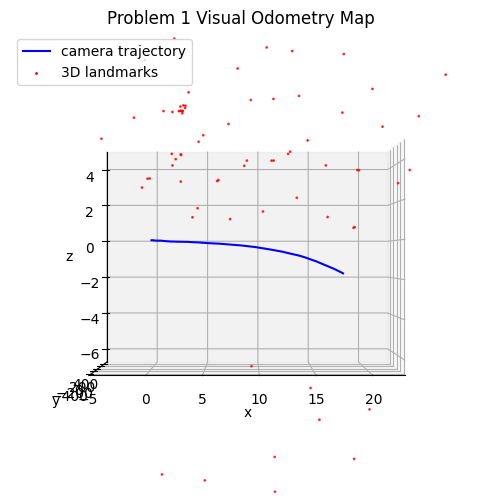

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')

ax.plot(T_W[0, :], T_W[1, :], T_W[2, :], 'b', label='camera trajectory')
ax.scatter(p_W[0, :], p_W[1, :], p_W[2, :], s=1, c='r', marker='o', label='3D landmarks')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Problem 1 Visual Odometry Map')
ax.view_init(elev=0., azim=-90)
ax.legend()

# These axis limits may need slight adjustment depending on scale drift.
ax.set_xlim(np.nanmin(T_W[0, :]) - 5, np.nanmax(T_W[0, :]) + 5)
ax.set_zlim(np.nanmin(T_W[2, :]) - 5, np.nanmax(T_W[2, :]) + 5)

plt.savefig(OUT_DIR / 'prob1_map.png', dpi=200, bbox_inches='tight')
plt.show()

In [11]:
image_files = sorted(OUT_DIR.glob('[0-9][0-9][0-9][0-9][0-9].png'))

if len(image_files) == 0:
    raise RuntimeError('No saved process images were found. Run the VO loop first with DISPLAY_PROCESS=True.')

first = cv2.imread(str(image_files[0]))
height, width = first.shape[:2]

codec = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(str(OUT_DIR / 'prob1.mp4'), codec, FPS, (width, height))

for file in image_files:
    frame = cv2.imread(str(file))
    if frame is None:
        continue
    frame = cv2.resize(frame, (width, height))
    out.write(frame)

out.release()
print('Saved:', OUT_DIR / 'prob1.mp4')

Saved: prob1_output\prob1.mp4


# Problem 2

Follow the directions in `project_prob2.ipynb`